# QCAP-style bounding: a 2-qubit example

**Goal of this notebook**
We simulate a small 2-qubit quantum processor with noise, then:
- use **RC (randomized compiling)** around a CZ gate to "twirl" errors,
- use **CB (cycle benchmarking)** to estimate the process infidelity $e_F$ of the
  *dressed cycle* the test circuits actually run,
- use a **readout confusion matrix** to estimate $r_o^{\rm fid}$, $r_o^{\rm std}$,
- plug those into the **QCAP bound** to predict how error grows with circuit depth,
- and compare the prediction to measured **TVD** and **Hellinger fidelity**.

This is meant to be pedagogical: every step is written out from scratch with only
`qiskit` + `qiskit-aer`, no `proxysim` import required.

## Correspondence to the rest of this repository

The notebook is standalone, but every formula below is the same one the package uses.
Each cell names the `proxysim` function it mirrors; this table is the summary.

| notebook | mirrors | note |
|---|---|---|
| `total_variation_distance`, `classical_fidelity`, `shannon_entropy` | `proxysim/metrics.py` | entropy is in **bits** (`log2`), as in `metrics.py` |
| `readout_confusion_fidelity` | `benchmarking.readout_fidelity` | (mean, std) of the confusion diagonal |
| `randomly_compile` | `proxysim/rc.py` `pauli_twirl` + `_merge_paulis` | twirl Paulis are **merged into the 1q layer**, so the twirled circuit is pulse-count (and therefore noise-budget) preserving |
| `cycle_benchmark` | `benchmarking.cycle_benchmark` | dressed cycle = 1q layer + CZ; $e_F=(1-4^{-n})(1-f)$ |
| `qcap_bound` | `benchmarking.qcap_bound` | verbatim port, including the uncertainty propagation |
| `make_layers` | `circuit.bench_brickwork(..., final_oneq=True)` | `depth` reps of [1q layer, CZ] + a trailing 1q layer |
| gate sets | `circuit.GATE_SETS` | `random` = Clifford + T (`run_bounding.py`'s `ONEQ_SET="t"`), `structured` = {I, H, X} |
| figures | `examples/run_bounding.py` | per-instance scatter + a 2.96σ band on the bound |

## 0) Background: what are we measuring?

A quantum circuit prepares a state, then we measure in the computational (Z) basis.

- A perfect circuit gives an *ideal* distribution $p(x)$.
- With noise we get a *measured* distribution $q(x)$.

So we need ways to compare distributions:
- **TVD** (total variation distance) — how distinguishable $p$ and $q$ are.
- **Hellinger fidelity** — a distribution fidelity.
- **Shannon entropy** of the ideal distribution, in **bits**, to study how the
  looseness of the bound correlates with how spread out the ideal output is.

And we need a way to understand how noise behaves across repeated "cycles" of the
gate. That is what RC and CB give us.

In [85]:
# !pip install qiskit qiskit-aer

In [86]:
# Imports

import itertools
import math

import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import Clifford, Operator, Pauli, Statevector, SuperOp
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel,
    ReadoutError,
    coherent_unitary_error,
    depolarizing_error,
)

from scipy.optimize import curve_fit

In [87]:
# Configuration.
#
# The constants mirror examples/run_bounding.py; the comment on each says which.

SEED = 42                        # run_bounding.py SEED
N_QUBITS = 2                     # run_bounding.py N

# Depth series to test, for both ansaetze.  run_bounding.py DEPTHS
DEPTHS = [1, 2, 4, 8, 16, 32, 64, 128]

# Random circuit instances per depth (the TVD scatter).  run_bounding.py N_INSTANCES=80
N_CIRC_PER_DEPTH = 40

# The entropy diagnostic is read at ONE depth, so the bound it is compared against is a
# single fixed number.  run_bound_vs_entropy.py DEPTH=8: "hold the circuit family and
# noise fixed so the CB bound is CONSTANT, and only vary the Shannon entropy".
ENTROPY_DEPTH = 16

# RC: N_RC independent Pauli-twirled randomizations, SHOTS_PER_RC shots each.  The
# measured distribution is their UNIFORM average -- the same estimator as
# examples/run_coherent_rc.py:rc_distribution.  Spelling both factors out (rather than
# the old `shots // n_rc`) keeps the shot budget exact.
N_RC = 30
SHOTS_PER_RC = 512
TOTAL_SHOTS = N_RC * SHOTS_PER_RC

# Cycle benchmarking.  Sequence lengths mirror run_bounding.py's [1,2,4,8,16,24] and
# run_bounding_renyi_focused_sem.py's [1,2,4,8,16,32,64]: the SMALL m are what anchor the
# fitted amplitude A, which is why the series must start at 1.
CB_DEPTHS = [1, 2, 4, 8, 16, 32, 64]
CB_N_RC = 20                     # randomizations per (Pauli, m)
CB_SHOTS = 4096

# Single-qubit gate sets, from proxysim.circuit.GATE_SETS.
#   "random"     = GATE_SETS["clifford"] + ["t"], i.e. run_bounding.py's ONEQ_SET="t".
#                  T keeps the ideal state non-stabilizer, which is what dissolves the
#                  banding in the TVD scatter (see run_bounding.py's module docstring).
#   "structured" = GATE_SETS["structured"].
ONEQ_SETS = {
    "random": ["h", "s", "sdg", "x", "y", "z", "sx", "sxdg", "t"],
    "structured": ["i", "h", "x"],
}
MODES = ("random", "structured")

# CB uses its OWN single-qubit dressing, drawn from the CLIFFORD sets
# (proxysim.benchmarking._ONEQ_RANDOM / _ONEQ_STRUCTURED).  run_bounding.py says why:
# "cycle_benchmark is untouched either way -- it keeps its own Clifford twirl layers,
# because the Pauli twirl the CB protocol relies on is a twirl over the Clifford group."
# The noise budget still matches the test circuit exactly: one single-qubit op per qubit
# per cycle either way, and the noise model charges a flat p1 per single-qubit op.
CB_ONEQ_SETS = {
    "random": ["h", "s", "sdg", "x", "y", "z", "sx", "sxdg"],
    "structured": ["i", "h", "x"],
}

# -------------------------
# Noise model parameters
# -------------------------
p1 = 1e-3          # 1-qubit depolarizing parameter (qiskit convention: f_P = 1 - p1)
p2 = 1e-2          # 2-qubit depolarizing parameter (f_P = 1 - p2 for P != II)
cz_overrot = 0.00  # coherent CZ over-rotation, rad
zz_angle = 0.00    # residual always-on ZZ coupling, rad
p_readout = 0.02   # symmetric readout error per qubit

# Both coherent terms are diagonal controlled-phase rotations, so they add: an
# over-rotated CZ is CZ . cp(eps), and residual ZZ coupling is another cp.  This is
# proxysim.noise.NoiseModel.theta_zz, described there as "residual cp(theta) coupling
# after each two-qubit gate" -- matching it is what makes the analytic twirl below, and
# the optional proxysim cross-check in section 9, apples-to-apples.
THETA_ZZ = cz_overrot + zz_angle

# The noise model's basis.  Every circuit is transpiled against the AerSimulator target
# at optimization_level=0, so the number of noisy operations is fixed by construction
# rather than by the transpiler's mood -- which is what lets us ASSERT that the twirled
# and untwirled circuits carry the same noise budget (see section 3).
BASIS_GATES = ["id", "x", "y", "z", "h", "s", "sdg", "sx", "sxdg", "t", "tdg",
               "rz", "u", "unitary", "cz", "measure"]

COLORS = {"measured": "#0072B2", "qcap": "#D55E00"}   # run_bounding.py palette

sim = AerSimulator()

## 1) The noise model

Real hardware has several error sources:

1. **Gate noise.**
   - a **coherent** error on CZ (a residual `cp(theta)` phase, i.e. an
     over-rotated CZ plus always-on ZZ coupling), and
   - **depolarizing** noise on both 1q and 2q gates.
2. **Readout noise**: measurement flips 0↔1 with some probability.

The single-qubit depolarizing channel is attached to *every* single-qubit gate name we
might emit, including `unitary` (the merged-twirl gates of section 3) and `id`. That
uniformity is deliberate: it is what makes "one single-qubit op per qubit per cycle"
equivalent to "one `p1` per qubit per cycle", which in turn is what lets the CB cycle
and the test-circuit cycle carry the same noise budget.

This mirrors `proxysim.benchmarking._apply_round`, which likewise charges `p1` on every
qubit of the single-qubit layer and `p2` (plus the ZZ term) on every entangling pair.

In [88]:
# Noise model

ONEQ_GATE_NAMES = ["id", "h", "x", "y", "z", "s", "sdg", "sx", "sxdg",
                   "t", "tdg", "rz", "u", "unitary"]


def cp_unitary(theta):
    """cp(theta) = diag(1, 1, 1, e^{i theta}) -- proxysim.noise's theta_zz term."""
    return np.diag([1.0, 1.0, 1.0, np.exp(1j * theta)]).astype(complex)


def build_noise_model(p1=p1, p2=p2, theta_zz=THETA_ZZ, p_readout=p_readout):
    nm = NoiseModel(basis_gates=BASIS_GATES)

    # 1-qubit depolarizing after every single-qubit gate name we can emit.
    nm.add_all_qubit_quantum_error(depolarizing_error(p1, 1), ONEQ_GATE_NAMES)

    # CZ carries a coherent cp(theta) error followed by 2-qubit depolarizing.
    cz_err = coherent_unitary_error(cp_unitary(theta_zz)).compose(
        depolarizing_error(p2, 2))
    nm.add_all_qubit_quantum_error(cz_err, ["cz"])

    # Symmetric readout error: 0->1 and 1->0 each with p_readout.
    nm.add_all_qubit_readout_error(
        ReadoutError([[1 - p_readout, p_readout], [p_readout, 1 - p_readout]]))
    return nm


noise_model = build_noise_model()
_s = math.sin(THETA_ZZ / 2) ** 2 / 4.0
print(f"coherent cp angle theta = {THETA_ZZ} rad")
print(f"  under RC this twirls EXACTLY to  p_IZ = p_ZI = p_ZZ = sin^2(theta/2)/4 = {_s:.6f}")
print(f"  (proxysim.noise.NoiseModel.twirled);  compare p2 = {p2} depolarizing on CZ")

coherent cp angle theta = 0.0 rad
  under RC this twirls EXACTLY to  p_IZ = p_ZI = p_ZZ = sin^2(theta/2)/4 = 0.000000
  (proxysim.noise.NoiseModel.twirled);  compare p2 = 0.01 depolarizing on CZ


## 2) Readout confusion matrix

Prepare each computational basis state, measure it under the noise model, and record

$$C[\text{prep}, \text{meas}] = \Pr(\text{meas} \mid \text{prep}).$$

From the diagonal we take

- **`ro_fid`** — the mean diagonal entry (how often readout is correct),
- **`ro_std`** — the standard deviation of the diagonal.

These are exactly the two numbers `proxysim.benchmarking.readout_fidelity` returns, and
they enter the QCAP bound as the SPAM factor.

Estimating readout metrics (ro_fid, ro_std) ...
  ro_fid = 0.960846
  ro_std = 0.000903
  confusion diagonal: [0.960693 0.961914 0.959473 0.961304]


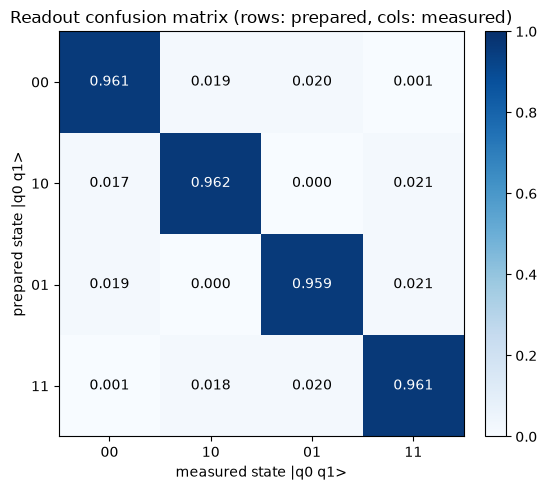

In [89]:
# Confusion matrix -- mirrors proxysim.benchmarking.readout_fidelity


def readout_confusion_fidelity(noise_model, shots=8192, seed=SEED):
    """Build C[prep, meas] by preparing each basis state and measuring it noisily.

    Returns (ro_fid, ro_std, C): the mean and standard deviation of the diagonal, plus
    the matrix itself.  Same estimator as benchmarking.readout_fidelity, which likewise
    returns (mean(diag), std(diag)).
    """
    n_states = 2 ** N_QUBITS
    circs = []
    for prep in range(n_states):
        qc = QuantumCircuit(N_QUBITS)
        for q in range(N_QUBITS):
            if (prep >> q) & 1:
                qc.x(q)
        qc.measure_all()
        circs.append(qc)

    circs = transpile(circs, sim, optimization_level=0)
    results = sim.run(circs, noise_model=noise_model, shots=shots,
                      seed_simulator=seed).result()

    C = np.zeros((n_states, n_states), dtype=float)
    for prep in range(n_states):
        for bs, v in results.get_counts(prep).items():
            b = bs.replace(" ", "")[::-1]          # -> index by qubit: b[q]
            C[prep, sum(int(b[q]) << q for q in range(N_QUBITS))] += v

    C /= C.sum(axis=1, keepdims=True)
    diag = np.diag(C)
    return float(np.mean(diag)), float(np.std(diag)), C


def idx_to_bitstring(i):
    """i -> 'q0q1', consistent with the confusion indexing i = q0 + 2*q1."""
    return "".join(str((i >> q) & 1) for q in range(N_QUBITS))


def plot_confusion_matrix(C, title="Readout confusion matrix"):
    labels = [idx_to_bitstring(i) for i in range(C.shape[0])]
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(C, vmin=0, vmax=1, cmap="Blues")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(C.shape[0]), labels)
    ax.set_yticks(range(C.shape[0]), labels)
    ax.set_xlabel("measured state |q0 q1>")
    ax.set_ylabel("prepared state |q0 q1>")
    ax.set_title(title)
    for i in range(C.shape[0]):
        for j in range(C.shape[1]):
            ax.text(j, i, f"{C[i, j]:.3f}", ha="center", va="center",
                    color="white" if C[i, j] > 0.55 else "black", fontsize=10)
    fig.tight_layout()
    plt.show()


print("Estimating readout metrics (ro_fid, ro_std) ...")
ro_fid, ro_std, C = readout_confusion_fidelity(noise_model, shots=8192)
print(f"  ro_fid = {ro_fid:.6f}")
print(f"  ro_std = {ro_std:.6f}")
print("  confusion diagonal:", np.round(np.diag(C), 6))

plot_confusion_matrix(C, title="Readout confusion matrix (rows: prepared, cols: measured)")

## 3) Randomized compiling around CZ

**Problem.** Our noise has both a coherent part (the residual `cp(theta)` phase) and a
stochastic part (depolarizing). Cycle benchmarking and the QCAP bound both assume the
error is a *Pauli* channel.

**RC (Pauli twirling).** Before each CZ apply a random Pauli $P$; after it apply the
compensating $P' = \mathrm{CZ}\,P\,\mathrm{CZ}^{-1}$, so
$$P'\,\mathrm{CZ}\,P = \pm\,\mathrm{CZ},$$
leaving the ideal action unchanged up to a global phase while conjugating the physical
error by a fresh random Pauli every randomization. Averaging over randomizations
projects the error channel onto its Pauli-diagonal part.

Two details matter for consistency, and both come straight from `proxysim/rc.py`.

**The conjugation table is derived, not hand-written.** `rc.py:_conjugation_table`
builds it from stim; here we build it from `Clifford(cz)`. A hand-typed 16-entry table
is exactly the kind of thing that silently rots.

**The twirl Paulis are merged into the single-qubit layer.** This is not cosmetic.
`rc.py` says it outright:

> a noise model that charges error per single-qubit *gate* would charge the twirled
> circuit more than the original and make RC look worse than it is, purely as an
> artefact of not compiling.

`rc.py` solves this with `mark_virtual`/`_merge_paulis`, whose stated property is being
*pulse-count preserving*; `examples/run_coherent_rc.py` has to set `p1 = 0` to dodge the
same bias. Aer has no "charge this gate nothing" hook, so we do what True-Q does on
hardware: fold each twirl Pauli into the neighbouring single-qubit gate and emit **one**
unitary per qubit per layer. The twirled circuit then has exactly the op count — and so
exactly the noise budget — of the untwirled one, and of the CB dressed cycle.

In [90]:
# Randomized compiling -- mirrors proxysim.rc.pauli_twirl + _merge_paulis

_PAULI_1Q = ("I", "X", "Y", "Z")
_PAULIS_2Q = tuple(a + b for a in _PAULI_1Q for b in _PAULI_1Q)   # index 0 = qubit 0

_SQRT_X = 0.5 * np.array([[1 + 1j, 1 - 1j], [1 - 1j, 1 + 1j]])
_MAT = {
    "i": np.eye(2, dtype=complex),
    "I": np.eye(2, dtype=complex),
    "x": np.array([[0, 1], [1, 0]], dtype=complex),
    "y": np.array([[0, -1j], [1j, 0]], dtype=complex),
    "z": np.array([[1, 0], [0, -1]], dtype=complex),
    "h": np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2),
    "s": np.array([[1, 0], [0, 1j]], dtype=complex),
    "sdg": np.array([[1, 0], [0, -1j]], dtype=complex),
    "sx": _SQRT_X,
    "sxdg": _SQRT_X.conj().T,
    "t": np.array([[1, 0], [0, np.exp(1j * np.pi / 4)]], dtype=complex),
}
_MAT["X"], _MAT["Y"], _MAT["Z"] = _MAT["x"], _MAT["y"], _MAT["z"]


def _pauli_label(p):
    """Phaseless 'q0q1' letters of a qiskit Pauli (qiskit labels are qubit-REVERSED)."""
    return "".join("IZXY"[int(p.x[q]) * 2 + int(p.z[q])] for q in range(len(p.z)))


def _build_cz_conjugation_table():
    """P -> letters of CZ P CZ^-1, derived from Clifford(cz).

    Signs are dropped: P' CZ P = +-CZ, and the sign is a global phase.  Same construction
    as proxysim.rc._conjugation_table, which derives it from stim instead.
    """
    qc = QuantumCircuit(2)
    qc.cz(0, 1)
    cl = Clifford(qc)
    table = {}
    for p in _PAULIS_2Q:
        # our strings index qubit 0 first; qiskit's Pauli labels are reversed
        table[p] = _pauli_label(Pauli(p[::-1]).evolve(cl))
    return table


CZ_CONJ = _build_cz_conjugation_table()

_MERGED_CACHE = {}


def _dephase(m):
    """Divide out a global phase so the first non-zero entry is positive real.

    Cosmetic in exact arithmetic -- and load-bearing in practice.  qiskit-aer 0.17.2
    mis-applies a DIAGONAL single-qubit ``unitary`` whose leading entry is a non-real
    phase: ``diag(-i, 1)`` is simulated as ``diag(1, -i)``, i.e. with the diagonal
    reversed.  (Reproduce: apply it to |+> and compare ``Statevector`` with
    ``AerSimulator(method="statevector")``.)  Nothing here is diagonal by accident --
    ``Z . s . I``-type merges are -- and the error is a relative phase, so it is
    invisible in the Z basis and only shows up once a later gate interferes the two
    branches.  Normalising the phase turns every diagonal merge into ``diag(1, x)``,
    which Aer handles correctly.  ``check_merged_gates()`` below asserts this.
    """
    flat = m.reshape(-1)
    k = int(np.argmax(np.abs(flat) > 1e-12))
    return m * np.exp(-1j * np.angle(flat[k]))


def merged_gate(p_after_prev, gate_name, p_this):
    """One UnitaryGate implementing  P_this · G · P_after_prev  (rightmost applied first).

    The merged unitary depends only on the three NAMES, and there are at most
    4 x |gate set| x 4 of them, so caching makes circuit construction cheap.

    NOTE, and this one costs you silently: do NOT give the gate a ``label``.  Aer's
    NoiseModel resolves noise by an instruction's *label* when it has one, and only falls
    back to its *name* otherwise.  A labelled ``UnitaryGate`` therefore matches no entry
    in a noise model registered against gate names and runs perfectly noiselessly --
    which here would have quietly removed every single-qubit error from the circuit while
    leaving the op counts looking correct.
    """
    key = (p_after_prev, gate_name, p_this)
    g = _MERGED_CACHE.get(key)
    if g is None:
        m = _dephase(_MAT[p_this] @ _MAT[gate_name] @ _MAT[p_after_prev])
        g = UnitaryGate(m)
        _MERGED_CACHE[key] = g
    return g


def check_merged_gates():
    """Assert Aer simulates every merged gate the way qiskit's Operator says it should.

    Probe: H, gate, H on |0>.  Sandwiching between Hadamards turns a *relative* phase
    error into a population difference, which a Z-basis measurement can see -- applying
    the gate alone could not.
    """
    for oneq in ONEQ_SETS.values():
        for p0 in _PAULI_1Q:
            for gname in oneq:
                for p1_ in _PAULI_1Q:
                    merged_gate(p0, gname, p1_)

    gates = list(_MERGED_CACHE.values())
    circs, want = [], []
    for g in gates:
        qc = QuantumCircuit(1)
        qc.h(0)
        qc.append(g, [0])
        qc.h(0)
        want.append(Statevector.from_instruction(qc).probabilities()[0])
        qc.measure_all()
        circs.append(qc)

    shots = 4096
    res = sim.run(transpile(circs, sim, optimization_level=0), shots=shots,
                  seed_simulator=SEED).result()
    worst = max(abs(res.get_counts(i).get("0", 0) / shots - w)
                for i, w in enumerate(want))
    assert worst < 0.05, f"Aer disagrees with Operator on a merged gate (max {worst:.3f})"
    return len(gates), worst


def build_circuit(layers, rng=None, measure=True):
    """Emit the brickwork circuit described by ``layers``, optionally Pauli-twirled.

    ``layers`` is a list of single-qubit gate-name lists, one per layer; a CZ follows
    every layer except the last.  This is the structure of
    ``proxysim.circuit.bench_brickwork(..., final_oneq=True)``: ``depth`` reps of
    [1q layer, CZ] plus a trailing single-qubit layer.

    With ``rng=None`` the named gates are emitted verbatim.  With an ``rng``, each CZ is
    wrapped in a random Pauli and its conjugate, and every Pauli is MERGED into the
    neighbouring single-qubit slot -- so both circuits emit exactly one single-qubit op
    per qubit per layer and carry the same noise budget.
    """
    qc = QuantumCircuit(N_QUBITS)
    n_cycles = len(layers) - 1
    carry = ["I"] * N_QUBITS          # correction Pauli owed by the previous cycle

    for j, layer in enumerate(layers):
        twirl = rng is not None and j < n_cycles
        pre = list(_PAULIS_2Q[rng.integers(len(_PAULIS_2Q))]) if twirl \
            else ["I"] * N_QUBITS
        for q in range(N_QUBITS):
            qc.append(merged_gate(carry[q], layer[q], pre[q]), [q])
        if j < n_cycles:
            qc.cz(0, 1)
            carry = list(CZ_CONJ["".join(pre)]) if twirl else ["I"] * N_QUBITS

    if measure:
        qc.measure_all()
    return qc


def rc_averaged_distribution(layers, noise_model, seed, n_rc=N_RC,
                             shots_per_rc=SHOTS_PER_RC):
    """Randomized compiling, done for real: the UNIFORM average of the distributions of
    ``n_rc`` independent Pauli-twirled randomizations.

    Same estimator as ``examples/run_coherent_rc.py:rc_distribution``.  Equal shots per
    randomization means summing counts *is* the uniform average, and the total budget is
    exactly ``n_rc * shots_per_rc``.
    """
    rng = np.random.default_rng(seed)
    circs = [build_circuit(layers, rng=rng) for _ in range(n_rc)]
    circs = transpile(circs, sim, optimization_level=0)
    res = sim.run(circs, noise_model=noise_model, shots=shots_per_rc,
                  seed_simulator=int(seed) % (2 ** 31)).result()

    total = {}
    for i in range(n_rc):
        for k, v in res.get_counts(i).items():
            total[k] = total.get(k, 0) + v
    norm = sum(total.values())
    return {k: v / norm for k, v in total.items()}


def tvd_shot_floor(n_outcomes=2 ** N_QUBITS, shots=TOTAL_SHOTS):
    """Rough finite-sampling floor on TVD for a near-uniform distribution.

    run_bounding.py documents its shot floor the same way (``TVD_SHOTS`` "sets the TVD
    noise floor (~0.003 here)"); stating it keeps a small measured TVD from being read as
    a real effect.
    """
    p = 1.0 / n_outcomes
    return 0.5 * n_outcomes * math.sqrt(2 * p * (1 - p) / (math.pi * shots))


_n_gates, _worst = check_merged_gates()
print(f"merged-gate check: {_n_gates} distinct gates, max Aer-vs-Operator deviation "
      f"{_worst:.4f}")
print(f"RC: {N_RC} randomizations x {SHOTS_PER_RC} shots = {TOTAL_SHOTS} shots per point")
print(f"    approximate TVD shot floor: {tvd_shot_floor():.4f}")
print("CZ conjugation table (from Clifford(cz)):",
      {k: CZ_CONJ[k] for k in ("XI", "IX", "XX", "XY", "ZZ")})

merged-gate check: 160 distinct gates, max Aer-vs-Operator deviation 0.0225
RC: 30 randomizations x 512 shots = 15360 shots per point
    approximate TVD shot floor: 0.0056
CZ conjugation table (from Clifford(cz)): {'XI': 'XZ', 'IX': 'ZX', 'XX': 'YY', 'XY': 'YX', 'ZZ': 'ZZ'}


## 4) Metrics: TVD, Hellinger fidelity, Shannon entropy

These are ports of `proxysim/metrics.py`, formula for formula.

**TVD**
$$\mathrm{TVD}(p,q) = \tfrac{1}{2}\sum_x |p(x)-q(x)| \in [0,1]$$

**Hellinger (classical) fidelity**
$$F_H(p,q)=\Big(\sum_x \sqrt{p(x)q(x)}\Big)^2 \in [0,1]$$

**Shannon entropy — in BITS**
$$H(p)=-\sum_x p(x)\log_2 p(x)$$

The base matters. `metrics.shannon_entropy` uses `log2` and every entropy axis in the
repo (`run_bound_vs_entropy.py`, the Rényi scripts) is labelled in bits; the earlier
version of this notebook used natural log, so its entropy axis was off by
$\ln 2 \approx 0.693$ against every other figure in the project.

In [91]:
# Metrics -- ports of proxysim/metrics.py


def ideal_probs(layers):
    """Ideal probabilities p(x) of the untwirled circuit, as a {bitstring: prob} dict."""
    return Statevector.from_instruction(
        build_circuit(layers, rng=None, measure=False)).probabilities_dict()


def total_variation_distance(p, q):
    """TVD = 1/2 sum_x |p(x) - q(x)|.   metrics.total_variation_distance"""
    keys = set(p) | set(q)
    return 0.5 * sum(abs(p.get(k, 0.0) - q.get(k, 0.0)) for k in keys)


def classical_fidelity(p, q):
    """Hellinger / classical fidelity  ( sum_x sqrt(p q) )^2.   metrics.classical_fidelity"""
    keys = set(p) | set(q)
    return sum(math.sqrt(p.get(k, 0.0) * q.get(k, 0.0)) for k in keys) ** 2


hellinger_fidelity = classical_fidelity


def shannon_entropy(dist):
    """Shannon entropy of a distribution, in BITS.   metrics.shannon_entropy"""
    return -sum(pr * math.log2(pr) for pr in dist.values() if pr > 0)

## 5) Cycle benchmarking: estimating $e_F$

CB measures how fast Pauli observables decay under repetition of a noisy *cycle*.

1. Pick a two-qubit Pauli $P$ and prepare its $+1$ eigenstate.
2. Apply the cycle $m$ times, each repetition randomly compiled.
3. Measure the Pauli the ideal circuit maps $P$ to, and record the signed survival.
4. Fit $\;\mathrm{survival}(m) = A\,f^{\,m}$.

SPAM robustness is the point: state-prep and readout errors scale $A$ but not $f$, so
$f$ — and therefore $e_F$ — is SPAM-independent. Readout enters the bound separately.

Three things here differ from the earlier version of this notebook, and all three are
needed for the bound to describe the circuit we actually measure.

**(a) The cycle is *dressed*.** The test circuits apply a single-qubit layer *and* a CZ
per cycle, so CB must benchmark the same thing.
`proxysim.benchmarking._apply_round` always includes the single-qubit layer, and
`run_bounding.py` runs CB once per ansatz (`mode=mode`). Benchmarking a bare CZ instead
omits $2p_1$ of depolarizing per cycle, which makes the bound too *tight* — it can then
be violated by the measured TVD, which is not a subtle failure mode.

**(b) The Heisenberg image of $P$ is tracked, with its sign.** After $m$ dressed cycles
the ideal circuit $C$ maps $P \mapsto C P C^{-1} = \pm P_m$, generally a *different*
Pauli. We compute it with `Pauli(P).evolve(Clifford(ideal))`, measure in $P_m$'s basis
on $P_m$'s support, and undo the sign so the noiseless value is $+1$ — exactly what
`benchmarking.cycle_benchmark` does via a stim tableau. Preparing and measuring the
*same* $P$ and then taking $|\cdot|$ only works when every $m$ is even and the cycle is
a bare CZ (since $\mathrm{CZ}^2=I$); with a dressing layer it fails outright.

**(c) The conversion to $e_F$ carries the $(d^2-1)/d^2$ factor.** The fitted $f$ is the
process *polarization*, not the infidelity. With $d=2^n$
(`benchmarking.py`, after Hashim et al. [2408.12064](https://arxiv.org/abs/2408.12064),
Table II):

$$e_F = \frac{d^2-1}{d^2}\,(1-f), \qquad r = \frac{d}{d+1}\,e_F, \qquad F_{\rm avg}=1-r.$$

At $n=2$ that factor is $15/16$; dropping it overstates $e_F$ by $6.7\%$, and the error
compounds as $(1-e_F)^d$ inside the bound.

One deliberate difference from the package: `cycle_benchmark` Monte-Carlo *samples*
random Paulis, because the group has $4^n$ elements and cannot be enumerated at
interesting $n$. At $n=2$ there are only 15 non-identity Paulis, so we enumerate all of
them — the same estimator with less variance. The cross-check in section 9 confirms the
two agree.

In [92]:
# CB helpers -- mirror proxysim.benchmarking

_PAULIS_2Q_NONID = tuple(p for p in _PAULIS_2Q if p != "II")


def prep_eigenstate(qc, letters):
    """Prepare the +1 eigenstate of Pauli ``letters`` from |0..0>.
    benchmarking._prep_eigenstate"""
    for q, ch in enumerate(letters):
        if ch == "X":
            qc.h(q)
        elif ch == "Y":
            qc.h(q)
            qc.s(q)              # S H |0> = |+i>, the +1 eigenstate of Y


def measure_rotation(qc, letters):
    """Rotate each Pauli factor to Z, so a Z-basis readout measures the Pauli.
    benchmarking._measure_rotation"""
    for q, ch in enumerate(letters):
        if ch == "X":
            qc.h(q)
        elif ch == "Y":
            qc.sdg(q)
            qc.h(q)


# QuantumCircuit method for each single-qubit gate name, so the IDEAL circuit is built
# from named Clifford gates -- Clifford() understands those, but not a raw `unitary`.
_QC_METHOD = {"i": "id", "h": "h", "x": "x", "y": "y", "z": "z", "s": "s",
              "sdg": "sdg", "sx": "sx", "sxdg": "sxdg"}


def evolved_pauli(layers, P):
    """(letters, sign) of the image  C P C^-1  of ``P`` under the ideal circuit ``C``.

    ``layers`` describes the ideal (untwirled) dressed cycles; the twirl contributes only
    a global phase per cycle, so it cannot affect the conjugation.  Mirrors the stim
    tableau step in benchmarking.cycle_benchmark:
    ``stim.PauliString(P).after(ideal.to_tableau())``.

    ``frame="s"`` is load-bearing.  Qiskit's ``Pauli.evolve`` defaults to ``frame="h"``,
    which returns C^-1 P C -- the *opposite* conjugation.  We prepare the eigenstate of P
    and measure at the END of the circuit, so the observable we need is C P C^-1, the
    Schroedinger image.  The two agree whenever C is self-inverse (a bare CZ cycle, which
    is why this is easy to miss), and disagree as soon as there is a dressing layer.
    """
    ideal = QuantumCircuit(N_QUBITS)
    n_cycles = len(layers) - 1
    for j, layer in enumerate(layers):
        for q in range(N_QUBITS):
            getattr(ideal, _QC_METHOD[layer[q]])(q)
        if j < n_cycles:
            ideal.cz(0, 1)
    out = Pauli(P[::-1]).evolve(Clifford(ideal), frame="s")
    return _pauli_label(out), float(np.real((-1j) ** out.phase))


def pauli_ev_from_counts(counts, letters, sign):
    """Sign-corrected expectation value of a Pauli from Z-basis counts."""
    support = [q for q, ch in enumerate(letters) if ch != "I"]
    if not support:
        return 1.0
    tot = acc = 0
    for bs, c in counts.items():
        b = bs.replace(" ", "")[::-1]                 # index by qubit
        parity = sum(int(b[q]) for q in support) % 2
        acc += c * (1 if parity == 0 else -1)
        tot += c
    return sign * acc / tot


def fit_decay(m, y, sigma=None):
    """Fit y = A f^m for f in (0,1], A in (0,1.2].  Returns (f, std_f).

    Verbatim structure of benchmarking._fit_decay, including the log-linear fallback.
    ``sigma`` (the SEM of each plotted mean) weights the fit; the unweighted version
    lets the noisiest large-m points pull the decay rate around.
    """
    def model(m, A, f):
        return A * f ** m

    kw = {}
    if sigma is not None:
        kw = {"sigma": np.maximum(np.asarray(sigma, float), 1e-6),
              "absolute_sigma": True}
    try:
        popt, pcov = curve_fit(model, m, y, p0=[max(y[0], 0.5), 0.99],
                               bounds=([0.0, 0.0], [1.2, 1.0]), maxfev=10000, **kw)
        return float(popt[1]), float(np.sqrt(max(pcov[1, 1], 0.0)))
    except Exception:
        mask = y > 1e-3
        slope = np.polyfit(m[mask], np.log(y[mask]), 1)[0]
        return float(np.exp(slope)), 0.0


def mean_sd_sem(vals):
    """(mean, s.d. with ddof=1, SEM).

    Matches run_bounding_renyi_focused_sem.py:_mean_sd_sem.  The plotted CB point is a
    MEAN over randomizations, so its error bar is the SEM, not the s.d.
    """
    a = np.asarray(vals, float)
    sd = float(a.std(ddof=1)) if a.size > 1 else 0.0
    return float(a.mean()), sd, sd / math.sqrt(a.size)

In [93]:
# Cycle benchmarking -- mirrors proxysim.benchmarking.cycle_benchmark


def cycle_benchmark(noise_model, mode, depths=CB_DEPTHS, n_rc=CB_N_RC,
                    shots=CB_SHOTS, seed=SEED):
    """Process infidelity e_F of the dressed cycle [1q layer, CZ] under ``noise_model``.

    For every sequence length m and every non-identity two-qubit Pauli P, we build
    ``n_rc`` independent randomizations (fresh single-qubit dressing + fresh Pauli twirl),
    prepare the +1 eigenstate of P, apply m cycles, and measure the sign-corrected
    survival of the ideal Heisenberg image of P.  The survivals are averaged over
    (P, randomization) and the resulting curve is fit ONCE to A f^m.

    The circuit is m repetitions of [1q layer, CZ] plus a trailing single-qubit layer
    that carries the last twirl's correction Pauli.  That trailing layer is
    m-independent, so it is absorbed into the fitted amplitude A and does not touch f --
    and it mirrors the test circuits, which are also ``depth`` cycles plus a trailing 1q
    layer (``bench_brickwork(..., final_oneq=True)``).
    """
    rng = np.random.default_rng(seed)
    oneq = CB_ONEQ_SETS[mode]

    decay, decay_sem, per_pauli = [], [], {P: [] for P in _PAULIS_2Q_NONID}
    for m in depths:
        circs, meta = [], []
        for P in _PAULIS_2Q_NONID:
            for _ in range(n_rc):
                layers = [[oneq[rng.integers(len(oneq))] for _ in range(N_QUBITS)]
                          for _ in range(m + 1)]
                letters, sign = evolved_pauli(layers, P)

                qc = QuantumCircuit(N_QUBITS)
                prep_eigenstate(qc, P)
                qc.compose(build_circuit(layers, rng=rng, measure=False),
                           inplace=True)
                measure_rotation(qc, letters)
                qc.measure_all()
                circs.append(qc)
                meta.append((P, letters, sign))

        circs = transpile(circs, sim, optimization_level=0)
        res = sim.run(circs, noise_model=noise_model, shots=shots,
                      seed_simulator=int(rng.integers(1 << 31))).result()

        vals, by_p = [], {P: [] for P in _PAULIS_2Q_NONID}
        for i, (P, letters, sign) in enumerate(meta):
            v = pauli_ev_from_counts(res.get_counts(i), letters, sign)
            vals.append(v)
            by_p[P].append(v)
        mean, _, sem = mean_sd_sem(vals)
        decay.append(mean)
        decay_sem.append(sem)
        for P in _PAULIS_2Q_NONID:
            per_pauli[P].append(mean_sd_sem(by_p[P]))

    m_arr = np.array(depths, float)
    f, f_std = fit_decay(m_arr, np.array(decay), sigma=decay_sem)

    # e_F = (d^2 - 1)/d^2 * (1 - f)   with d = 2^n.   benchmarking.cycle_benchmark
    factor = 1.0 - 4.0 ** (-N_QUBITS)
    e_F, e_F_std = factor * (1.0 - f), factor * f_std
    d = 2.0 ** N_QUBITS
    r = d / (d + 1.0) * e_F                        # average gate infidelity, Table II

    # Per-Pauli decays.  The dressing layer is redrawn every randomization, so each
    # Pauli's trajectory through the circuit is uniformly random and every one of these
    # estimates the SAME twirled polarization f.  Their spread is therefore a
    # consistency check on the protocol, not a Pauli spectrum -- section 6 plots them
    # against the exact spectrum to make that explicit.
    pauli_fits = {}
    for P, rows in per_pauli.items():
        means = np.array([r_[0] for r_ in rows])
        sems = np.array([r_[2] for r_ in rows])
        fP, fP_std = fit_decay(m_arr, means, sigma=sems)
        pauli_fits[P] = {"f": fP, "f_std": fP_std, "means": means, "sems": sems}

    return {"depths": list(depths), "decay": np.array(decay),
            "decay_sem": np.array(decay_sem), "f": f, "f_std": f_std,
            "e_F": e_F, "e_F_std": e_F_std, "F_e": 1.0 - e_F,
            "r": r, "F_avg": 1.0 - r, "pauli_fits": pauli_fits}

## 6) What CB is estimating, exactly

For this noise model we can write the answer down, which turns section 5 from a
demonstration into a test.

Write the physical cycle as $\Lambda\circ\mathcal{C}$, where $\mathcal{C}$ is the ideal
cycle (dressing $G$, then CZ) and $\Lambda$ is the error channel that follows it:

$$\Lambda \;=\; \mathcal{E}_2 \circ \mathrm{Ad}_{\rm CZ}\circ(\mathcal{D}_1\otimes
  \mathcal{D}_1)\circ \mathrm{Ad}_{\rm CZ}^{-1}.$$

The dressing cancels: $\mathrm{Ad}_G$ and $\mathrm{Ad}_G^{-1}$ sit on either side of a
tensor product of depolarizing channels, which is unitarily covariant. **So $e_F$ does
not depend on which single-qubit gates dress the cycle** — which is exactly why CB may
use its own Clifford dressing while the test circuits use Clifford+T, and why
`run_bounding.py` can say "`cycle_benchmark` is untouched either way".

Under RC the coherent $\mathrm{cp}(\theta)$ becomes a Pauli channel with
$p_{IZ}=p_{ZI}=p_{ZZ}=\sin^2(\theta/2)/4$ — the closed form in
`proxysim.noise.NoiseModel.twirled`. Everything is then Pauli-diagonal and, for
$P\neq II$,

$$f_P \;=\; (1-p_2)\,\Big(1-2\!\!\sum_{Q:\,\{P,Q\}=0}\!\!p_Q\Big)\,
           (1-p_1)^{|{\rm CZ}\,P\,{\rm CZ}|},$$

where $|\cdot|$ is the number of qubits the Pauli acts on non-trivially, and
$e_F = 1 - 4^{-n}\sum_P f_P$. The `SuperOp` construction below is an independent check
of that algebra: it builds $\Lambda$ from the same Aer error objects the simulator uses
and reads off $f_P = \mathrm{Tr}[P\,\Lambda(P)]/d$.

One warning about reading the spectrum plot that follows. The individual $f_P$ here
range over a factor of $\sim 1.5$, but a CB decay labelled by its *starting* Pauli does
not measure that Pauli's $f_P$: the random dressing layer walks the Pauli around its
orbit, so the decay it produces is the geometric mean of $f$ along that walk. For a
scrambling gate set every starting Pauli therefore gives back roughly the same
number — $e_F$. That self-averaging is a feature, not an artefact; it is what makes one
fitted $f$ a fair summary of fifteen rates. Recovering the spectrum itself needs a
fixed dressing (interleaved CB), which is a different experiment.

In [94]:
# Exact Pauli spectrum of the twirled dressed cycle


def _anticommute(a, b):
    """Do two Pauli strings (same length, q0 first) anticommute?"""
    return sum(1 for x, y in zip(a, b) if x != "I" and y != "I" and x != y) % 2 == 1


def exact_pauli_fidelities(p1=p1, p2=p2, theta_zz=THETA_ZZ):
    """Closed-form f_P of the twirled dressed-cycle error channel."""
    s = math.sin(theta_zz / 2.0) ** 2 / 4.0        # noise.NoiseModel.twirled()
    coherent_rates = {"IZ": s, "ZI": s, "ZZ": s}
    out = {}
    for P in _PAULIS_2Q:
        if P == "II":
            out[P] = 1.0
            continue
        coh = 1.0 - 2.0 * sum(v for Q, v in coherent_rates.items()
                              if _anticommute(P, Q))
        weight = sum(1 for ch in CZ_CONJ[P] if ch != "I")
        out[P] = (1.0 - p2) * coh * (1.0 - p1) ** weight
    return out


def superop_pauli_fidelities(p1=p1, p2=p2, theta_zz=THETA_ZZ):
    """The same f_P, built from Aer's own error channels -- an independent check."""
    d1 = SuperOp(depolarizing_error(p1, 1))
    cz = SuperOp(Operator(np.diag([1.0, 1.0, 1.0, -1.0]).astype(complex)))
    e2 = SuperOp(Operator(cp_unitary(theta_zz))).compose(
        SuperOp(depolarizing_error(p2, 2)))

    full = d1.tensor(d1).compose(cz).compose(e2)   # A.compose(B) applies B after A
    lam = cz.adjoint().compose(full)               # = full . Ad_CZ^-1

    out = {}
    for P in _PAULIS_2Q:
        mat = Pauli(P[::-1]).to_matrix()
        img = (lam.data @ mat.reshape(-1, order="F")).reshape(mat.shape, order="F")
        out[P] = float(np.real(np.trace(mat.conj().T @ img) / 2.0 ** N_QUBITS))
    return out


def exact_e_F(**kw):
    return 1.0 - sum(exact_pauli_fidelities(**kw).values()) / 4.0 ** N_QUBITS


_closed, _super = exact_pauli_fidelities(), superop_pauli_fidelities()
_gap = max(abs(_closed[P] - _super[P]) for P in _PAULIS_2Q)
assert _gap < 1e-12, f"closed form disagrees with the SuperOp construction ({_gap:.2e})"
print(f"closed form vs SuperOp: max |delta f_P| = {_gap:.2e}")
print(f"exact e_F of the dressed cycle = {exact_e_F():.8f}")
print(f"        r = {2 ** N_QUBITS / (2 ** N_QUBITS + 1) * exact_e_F():.8f}")

closed form vs SuperOp: max |delta f_P| = 1.11e-16
exact e_F of the dressed cycle = 0.01085944
        r = 0.00868755


In [95]:
# ============================================================
# CB plots
# ============================================================

def _fit_amplitude(xs, means, sems, f):
    """
    Fit only A in

        y(m) = A f^m

    while holding the supplied decay factor f fixed.
    """
    xs = np.asarray(xs, dtype=float)
    means = np.asarray(means, dtype=float)
    sems = np.asarray(sems, dtype=float)

    basis = np.power(f, xs)
    safe_sems = np.maximum(sems, 1e-8)
    weights = 1.0 / safe_sems**2

    denominator = np.sum(weights * basis**2)

    if denominator > 0 and np.isfinite(denominator):
        numerator = np.sum(weights * basis * means)
        return float(numerator / denominator)

    if abs(basis[0]) > 1e-14:
        return float(means[0] / basis[0])

    return float(means[0])


def plot_cb_decay(cbs):
    """
    Plot every starting-Pauli CB trajectory separately.

    Important
    ---------
    These are starting-Pauli, orbit-averaged CB decays. Because the
    single-qubit dressing is redrawn, they are generally not the
    individual interaction-frame channel eigenvalues f_P.

    One figure is produced for each circuit mode. The thick dashed
    curve is the old all-Pauli average.
    """
    for mode, cb in cbs.items():
        xs = np.asarray(cb["depths"], dtype=float)
        grid = np.linspace(xs.min(), xs.max(), 400)

        fig, ax = plt.subplots(figsize=(12, 7))

        # Separate starting-Pauli curves.
        for P in _PAULIS_2Q_NONID:
            fit = cb["pauli_fits"][P]

            means = np.asarray(fit["means"], dtype=float)
            sems = np.asarray(fit["sems"], dtype=float)
            f_orbit = float(fit["f"])

            A_P = _fit_amplitude(
                xs,
                means,
                sems,
                f_orbit,
            )

            line, = ax.plot(
                grid,
                A_P * np.power(f_orbit, grid),
                linewidth=1.4,
                label=rf"{P}: $f_{{\rm orbit}}={f_orbit:.6f}$",
            )

            ax.errorbar(
                xs,
                means,
                yerr=sems,
                fmt="o",
                markersize=3,
                capsize=2,
                linestyle="none",
                color=line.get_color(),
            )

        # Original all-Pauli averaged CB curve.
        avg_means = np.asarray(cb["decay"], dtype=float)
        avg_sems = np.asarray(cb["decay_sem"], dtype=float)
        avg_f = float(cb["f"])

        avg_A = _fit_amplitude(
            xs,
            avg_means,
            avg_sems,
            avg_f,
        )

        ax.plot(
            grid,
            avg_A * np.power(avg_f, grid),
            linestyle="--",
            linewidth=3,
            label=rf"all-Pauli average: $f={avg_f:.6f}$",
        )

        ax.set_xlabel("sequence length $m$ (dressed cycles)")
        ax.set_ylabel("signed Pauli survival")
        ax.set_title(
            f"{mode} CB: separate trajectory for every starting Pauli"
        )
        ax.grid(True, alpha=0.3)
        ax.legend(
            frameon=False,
            fontsize=8,
            ncol=3,
        )

        fig.tight_layout()
        plt.show()


def plot_cb_pauli_spectrum(cb, exact, title=""):
    """
    Compare two different quantities:

    1. Actual interaction-frame Pauli losses:
           1 - f_P

    2. Starting-Pauli CB losses:
           1 - f_orbit,P

       These are orbit-averaged because the dressing is redrawn.

    The horizontal lines are placed on the same 1-f scale as the
    plotted data. Process infidelities e_F are reported separately
    in the title.
    """
    order = list(_PAULIS_2Q_NONID)
    x = np.arange(len(order))

    # Actual individual Pauli-channel losses.
    exact_losses = np.array(
        [1.0 - float(exact[P]) for P in order],
        dtype=float,
    )

    # Orbit-averaged starting-P CB losses.
    cb_losses = np.array(
        [
            1.0 - float(cb["pauli_fits"][P]["f"])
            for P in order
        ],
        dtype=float,
    )

    cb_errors = np.array(
        [
            float(cb["pauli_fits"][P]["f_std"])
            for P in order
        ],
        dtype=float,
    )

    # Mean polarization losses, on the same vertical scale.
    exact_f_bar = np.mean(
        [float(exact[P]) for P in order]
    )
    exact_polarization_loss = 1.0 - exact_f_bar

    cb_polarization_loss = 1.0 - float(cb["f"])

    # Convert polarization loss to process infidelity.
    factor = 1.0 - 4.0 ** (-N_QUBITS)

    exact_e_F = factor * exact_polarization_loss
    cb_e_F = float(cb["e_F"])

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.bar(
        x,
        exact_losses,
        alpha=0.75,
        label=r"actual channel loss $1-f_P$",
    )

    ax.errorbar(
        x,
        cb_losses,
        yerr=cb_errors,
        fmt="d",
        markersize=6,
        capsize=3,
        linestyle="none",
        label=(
            r"starting-P CB loss $1-f_{\rm orbit,P}$"
            "\n"
            "(orbit-averaged, not the individual channel eigenvalue)"
        ),
    )

    ax.axhline(
        exact_polarization_loss,
        linestyle="--",
        linewidth=1.5,
        label=(
            rf"exact $1-\bar f={exact_polarization_loss:.6f}$"
        ),
    )

    ax.axhline(
        cb_polarization_loss,
        linestyle=":",
        linewidth=1.8,
        label=(
            rf"CB $1-f={cb_polarization_loss:.6f}$"
        ),
    )

    ax.set_xticks(
        x,
        order,
        rotation=45,
        ha="right",
    )

    ax.set_xlabel(
        "Pauli label  (index 0 = qubit 0)"
    )
    ax.set_ylabel("per-cycle loss")
    ax.set_title(
        title
        or (
            "Actual Pauli-channel losses versus "
            "randomized-dressing CB losses\n"
            rf"exact $e_F={exact_e_F:.6f}$, "
            rf"CB $e_F={cb_e_F:.6f}$"
        )
    )

    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(
        frameon=False,
        fontsize=9,
    )

    fig.tight_layout()
    plt.show()


def plot_exact_pauli_channel_decays(
    exact=None,
    depths=None,
):
    """
    Plot all actual interaction-frame Pauli eigenchannel decays:

        f_P^m

    These curves are computed directly from the exact Pauli
    eigenvalues. They are not orbit-averaged CB trajectories.
    """
    if exact is None:
        exact = exact_pauli_fidelities()

    if depths is None:
        depths = CB_DEPTHS

    xs = np.asarray(depths, dtype=float)
    grid = np.linspace(0.0, xs.max(), 400)

    fig, ax = plt.subplots(figsize=(12, 7))

    for P in _PAULIS_2Q_NONID:
        f_P = float(exact[P])

        line, = ax.plot(
            grid,
            np.power(f_P, grid),
            linewidth=1.5,
            label=rf"{P}: $f_P={f_P:.8f}$",
        )

        # Mark the actual CB sequence lengths.
        ax.plot(
            xs,
            np.power(f_P, xs),
            "o",
            markersize=3,
            color=line.get_color(),
        )

    ax.set_xlabel("number of channel applications $m$")
    ax.set_ylabel(r"actual eigenchannel decay $f_P^m$")
    ax.set_title(
        "Actual Pauli eigenchannels of the interaction-frame error map"
    )
    ax.grid(True, alpha=0.3)
    ax.legend(
        frameon=False,
        fontsize=8,
        ncol=3,
    )

    fig.tight_layout()
    plt.show()

## 7) The QCAP bound

Given a process infidelity per cycle and a readout fidelity, bound the probability that
a depth-$d$ circuit produces a wrong answer. Multiply the surviving fidelities:

$$F \;=\; r_o^{\rm fid}\prod_c (1-e_F^{(c)})^{\,n_c},
  \qquad \varepsilon_{\rm bound} = 1 - F,$$

with $n_c$ the number of applications of cycle $c$. At $n=2$ there is a single cycle
type (the one CZ pair), so $n_c = d$.

This is `proxysim.benchmarking.qcap_bound`, ported below with its signature and its
`{"error", "std", "fidelity"}` return intact.

**The uncertainty.** With $y = (1-e_F)^{n}$, first-order propagation gives

$$\sigma_y^2 = \Big(\frac{\partial y}{\partial e_F}\Big)^{\!2}\sigma_{e_F}^2
             = \big(n(1-e_F)^{n-1}\big)^2\,\sigma_{e_F}^2 .$$

The derivative is **squared**. An earlier version of this notebook wrote
`n * (1-e_F)**(n-1) * e_F_std**2` — the derivative to the first power, which is not a
variance of anything. Writing $D = n(1-e_F)^{n-1}$, the two differ by
$\sqrt{D\sigma^2}/\sqrt{D^2\sigma^2} = 1/\sqrt D$, so the mistake *shrinks* the band
whenever $D>1$: at $e_F=0.01$, $\sigma_{e_F}=10^{-3}$, $d=128$ it gives $0.006$ where
the correct $\sigma_y$ is $0.036$, a factor of 6 too **narrow**. (It errs the other way
only at small depth, where $D<1$.) An error bar that is too small is the bad direction
to be wrong in — it makes a bound look better-determined than it is.
Products then combine exactly rather than to first order,
$\mathrm{Var}(XY) = y^2\sigma_p^2 + p^2\sigma_y^2 + \sigma_p^2\sigma_y^2$
for independent $X, Y$.

In [96]:
# QCAP bound -- verbatim port of proxysim.benchmarking.qcap_bound


def qcap_bound(cycle_counts, cycle_efs, ro_fid, ro_std):
    """Bound the error probability of a circuit from per-cycle infidelities.

    cycle_counts : {cycle key: how many times that cycle is applied}
    cycle_efs    : {cycle key: (e_F, e_F_std)}
    ro_fid, ro_std : readout fidelity and its uncertainty.
    """
    p = ro_fid
    pvar = ro_std ** 2
    for cyc, n in cycle_counts.items():
        e_F, std = cycle_efs[cyc]
        y = (1.0 - e_F) ** n
        dy_de = -n * (1.0 - e_F) ** (n - 1)
        yvar = dy_de ** 2 * std ** 2                  # note the SQUARE
        p_new = p * y
        pvar_new = (y ** 2 * pvar + p ** 2 * yvar + pvar * yvar)
        p, pvar = p_new, pvar_new
    return {"error": 1.0 - p, "std": math.sqrt(max(pvar, 0.0)), "fidelity": p}


# At n=2 the brickwork has a single entangling pair, so a single cycle type.
# proxysim.even_pairs(2) == [(0, 1)] and odd_pairs(2) == [] -- run_bounding.py drops the
# empty layer explicitly, "benchmarking it returns a spurious non-zero e_F ... and
# qcap_bound would then charge the bound for a cycle the circuit never applies".
CYCLE_KEY = "A"

## 8) The two circuit families

Both are brickwork: `depth` repetitions of [single-qubit layer, CZ], plus a trailing
single-qubit layer. That is `proxysim.circuit.bench_brickwork(..., final_oneq=True)`,
which `run_bounding.py:test_circuit` uses.

- **random** — 1q gates drawn from `GATE_SETS["clifford"] + ["t"]`, i.e.
  `run_bounding.py`'s `ONEQ_SET = "t"`. The T gate makes the ideal state
  non-stabilizer, which is what dissolves the discrete banding in the TVD scatter.
- **structured** — drawn from `GATE_SETS["structured"] = {I, H, X}`, a much smaller
  orbit, so the ideal distributions repeat and the scatter is banded.

The identity is emitted **explicitly**. `benchmarking._apply_round` appends `i` and
charges it $p_1$ like any other gate; dropping it would quietly give that qubit a free
cycle and make the measured error fall below a bound that assumed it paid.

One caveat, inherited from the repo: the bound charges `depth` cycles and does *not*
charge the trailing single-qubit layer. That layer costs $2p_1 \approx 0.002$ of
fidelity, so the bound is optimistic by about that much, independent of depth. CB's
fitted amplitude absorbs the same layer, so the two stay consistent with each other.

In [97]:
# Circuit families -- mirror proxysim.circuit.bench_brickwork(..., final_oneq=True)


def make_layers(mode, depth, seed):
    """`depth`+1 single-qubit layers; a CZ follows all but the last."""
    rng = np.random.default_rng(seed)
    gates = ONEQ_SETS[mode]
    return [[gates[rng.integers(len(gates))] for _ in range(N_QUBITS)]
            for _ in range(depth + 1)]


def n_oneq_ops(depth):
    return N_QUBITS * (depth + 1)


for _mode in MODES:
    _l = make_layers(_mode, 3, SEED)
    _c = transpile(build_circuit(_l, rng=np.random.default_rng(0)), sim,
                   optimization_level=0)
    _ops = dict(_c.count_ops())
    assert _ops.get("unitary") == n_oneq_ops(3) and _ops.get("cz") == 3, _ops
    print(f"{_mode:11} depth 3 -> {_ops['unitary']} single-qubit ops, {_ops['cz']} CZ  "
          f"(layers: {[''.join(x) for x in _l]})")

random      depth 3 -> 8 single-qubit ops, 3 CZ  (layers: ['hsx', 'zx', 'xsxdg', 'hsx'])
structured  depth 3 -> 8 single-qubit ops, 3 CZ  (layers: ['ix', 'hh', 'hx', 'ix'])


## 9) Running the experiment

For each ansatz and each depth we draw `N_CIRC_PER_DEPTH` random instances, each with
its **own** seed `SEED + 100*i` — the stride is `run_bounding.py:206`'s, and it leaves
room for an independent shot seed. Sharing one RNG across instances would give every
point the same shot-noise realisation and understate the spread.

Per instance we record the ideal distribution, the RC-averaged measured distribution,
and from them the TVD, the Hellinger fidelity, and the ideal distribution's Shannon
entropy in bits.

Figures follow `run_bounding.py:238-258`: per-instance scatter in `#0072B2`, the bound
as a line in `#D55E00`, and a filled $\pm 2.96\sigma$ band. (2.96σ is the two-sided
99.7% normal interval — the same convention the repo's bounding figures use. Here the
band is narrower than the line: $\sigma_{\rm bound}\approx 0.002$ even at depth 128,
because `e_F` is pinned to $10^{-4}$ by fitting seven depths.)

The entropy diagnostic is then read at the single depth `ENTROPY_DEPTH`, following
`run_bound_vs_entropy.py`, which fixes its depth so the bound it plots against is
constant. Pooling depths would confound entropy with depth: both grow together, so a
rising gap would be evidence of nothing.

In [98]:
# Main experiment loop


def run_mode(mode, cb, ro_fid, ro_std, depths=DEPTHS, n_inst=N_CIRC_PER_DEPTH):
    efs = {CYCLE_KEY: (cb["e_F"], cb["e_F_std"])}
    out = {"depths": list(depths), "bound": [], "bound_std": [],
           "tvd": [], "hellinger": [], "entropy": []}

    print(f"  {'depth':>6}{'bound':>10}{'TVD (mean)':>12}{'F_H (mean)':>12}"
          f"{'H bits':>9}")
    for d in depths:
        b = qcap_bound({CYCLE_KEY: d}, efs, ro_fid, ro_std)
        out["bound"].append(b["error"])
        out["bound_std"].append(b["std"])

        tvds, fhs, ents = [], [], []
        for i in range(n_inst):
            s = SEED + 100 * i            # per-instance seed, run_bounding.py:206
            layers = make_layers(mode, d, s)
            p = ideal_probs(layers)
            q = rc_averaged_distribution(layers, noise_model, seed=s + 1)
            tvds.append(total_variation_distance(p, q))
            fhs.append(classical_fidelity(p, q))
            ents.append(shannon_entropy(p))
        out["tvd"].append(tvds)
        out["hellinger"].append(fhs)
        out["entropy"].append(ents)
        print(f"  {d:>6}{b['error']:>10.4f}{np.mean(tvds):>12.4f}"
              f"{np.mean(fhs):>12.4f}{np.mean(ents):>9.3f}", flush=True)
    return out


def plot_bound_vs_depth(data, ylabel, key, transform=lambda v: v, title=""):
    """run_bounding.py's figure: per-instance scatter + bound + 2.96 sigma band."""
    fig, axes = plt.subplots(1, len(MODES), figsize=(12, 4.8), sharey=True)
    for ax, mode in zip(np.atleast_1d(axes), MODES):
        dat = data[mode]
        b = np.array(dat["bound"])
        bs = np.array(dat["bound_std"])
        for d, vals in zip(dat["depths"], dat[key]):
            ax.plot([d] * len(vals), vals, "o", color=COLORS["measured"], ms=5,
                    alpha=0.7,
                    label="measured, randomly compiled" if d == dat["depths"][0]
                    else None)
        ax.plot(dat["depths"], transform(b), "-", color=COLORS["qcap"], lw=2,
                label="QCAP bound (on the RC'd circuit)")
        ax.fill_between(dat["depths"], transform(b - 2.96 * bs),
                        transform(b + 2.96 * bs), color=COLORS["qcap"], alpha=0.2)
        ax.set_xlabel("circuit depth")
        ax.set_title(f"{mode} ansatz", fontsize=11)
        ax.grid(True, which="both", alpha=0.15)
        ax.legend(frameon=False, fontsize=8.5)
    np.atleast_1d(axes)[0].set_ylabel(ylabel)
    fig.suptitle(title, fontsize=12)
    fig.tight_layout()
    plt.show()


def plot_gap_vs_entropy(data, depth=ENTROPY_DEPTH, n_bins=5):
    """Bound looseness against the ideal distribution's entropy, at FIXED depth.

    The design is run_bound_vs_entropy.py's, and the fixed depth is the whole point of
    it: "hold the circuit family and noise fixed so the CB bound is CONSTANT, and only
    vary the Shannon entropy of the ideal output distribution".  Pooling depths instead
    would confound the two -- deeper circuits have both a larger bound and (here) a more
    spread output, so a rising trend would prove nothing.  With depth fixed the bound is
    a single horizontal line and every point on the x axis is compared against it.

    Two panels, as in that script: TVD against entropy, and the gap.  Entropy is log2,
    so the axis is bits (metrics.shannon_entropy); the earlier version of this notebook
    used natural log and was off by ln 2 against every other figure in the repository.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    edges = np.linspace(0.0, float(N_QUBITS), n_bins + 1)

    for i, mode in enumerate(MODES):
        dat = data[mode]
        j = dat["depths"].index(depth)
        H = np.asarray(dat["entropy"][j])
        tvd = np.asarray(dat["tvd"][j])
        bound = dat["bound"][j]
        gap = bound - tvd
        col = f"C{i}"

        ax1.plot(H, tvd, "o", ms=4, alpha=0.35, color=col)
        ax2.plot(H, gap, "o", ms=4, alpha=0.35, color=col)

        idx = np.clip(np.digitize(H, edges) - 1, 0, n_bins - 1)
        for ax, y in ((ax1, tvd), (ax2, gap)):
            xs, ys, es = [], [], []
            for k in range(n_bins):
                sel = idx == k
                if sel.sum() < 2:
                    continue
                xs.append(H[sel].mean())
                ys.append(y[sel].mean())
                es.append(y[sel].std(ddof=1))
            ax.errorbar(xs, ys, yerr=es, fmt="o-", capsize=3, color=col, lw=2,
                        label=f"{mode} (binned mean $\\pm$ s.d.)")

    # the bound is one number here -- that is what fixing the depth bought us
    b = data[MODES[0]]["bound"][data[MODES[0]]["depths"].index(depth)]
    ax1.axhline(b, color=COLORS["qcap"], lw=2, label=f"QCAP bound (fixed) = {b:.3f}")
    ax2.axhline(0.0, color="k", lw=1, ls="--")
    for ax, lab, ttl in ((ax1, "probability of an error (TVD)",
                          "bound is fixed; TVD varies with the output spread"),
                         (ax2, "bound $-$ measured TVD",
                          "so the gap opens up with entropy")):
        ax.set_xlabel("Shannon entropy of the ideal distribution (bits)")
        ax.set_ylabel(lab)
        ax.set_title(ttl, fontsize=11)
        ax.grid(True, alpha=0.2)
        ax.legend(frameon=False, fontsize=9)
    fig.suptitle(f"Bound looseness vs output entropy  (depth {depth} held fixed, "
                 f"{N_CIRC_PER_DEPTH} instances per ansatz)", fontsize=12)
    fig.tight_layout()
    plt.show()

In [99]:
# Run everything

ro_fid, ro_std, confusion = readout_confusion_fidelity(noise_model)
cbs, results = {}, {}
for mode in MODES:
    print(f"\n=== {mode} ansatz ===")
    cbs[mode] = cycle_benchmark(noise_model, mode)
    cb = cbs[mode]
    print(f"  e_F = {cb['e_F']:.5f} +- {cb['e_F_std']:.5f}   (exact {exact_e_F():.5f})")
    print(f"  r   = {cb['r']:.5f}   F_avg = {cb['F_avg']:.5f}")
    print(f"  readout fidelity: {ro_fid:.4f} ({ro_std:.4f})")
    results[mode] = run_mode(mode, cb, ro_fid, ro_std)


=== random ansatz ===
  e_F = 0.01082 +- 0.00003   (exact 0.01086)
  r   = 0.00865   F_avg = 0.99135
  readout fidelity: 0.9608 (0.0009)
   depth     bound  TVD (mean)  F_H (mean)   H bits
       1    0.0495      0.0297      0.9715    0.925
       2    0.0598      0.0299      0.9722    1.100
       4    0.0801      0.0391      0.9640    1.145
       8    0.1192      0.0445      0.9668    1.355
      16    0.1926      0.0658      0.9723    1.559
      32    0.3216      0.1010      0.9629    1.592
      64    0.5210      0.1710      0.9346    1.597
     128    0.7612      0.2535      0.8882    1.562

=== structured ansatz ===
  e_F = 0.01085 +- 0.00003   (exact 0.01086)
  r   = 0.00868   F_avg = 0.99132
  readout fidelity: 0.9608 (0.0009)
   depth     bound  TVD (mean)  F_H (mean)   H bits
       1    0.0496      0.0322      0.9686    0.850
       2    0.0599      0.0309      0.9707    1.125
       4    0.0802      0.0375      0.9642    1.200
       8    0.1194      0.0545      0.9473  

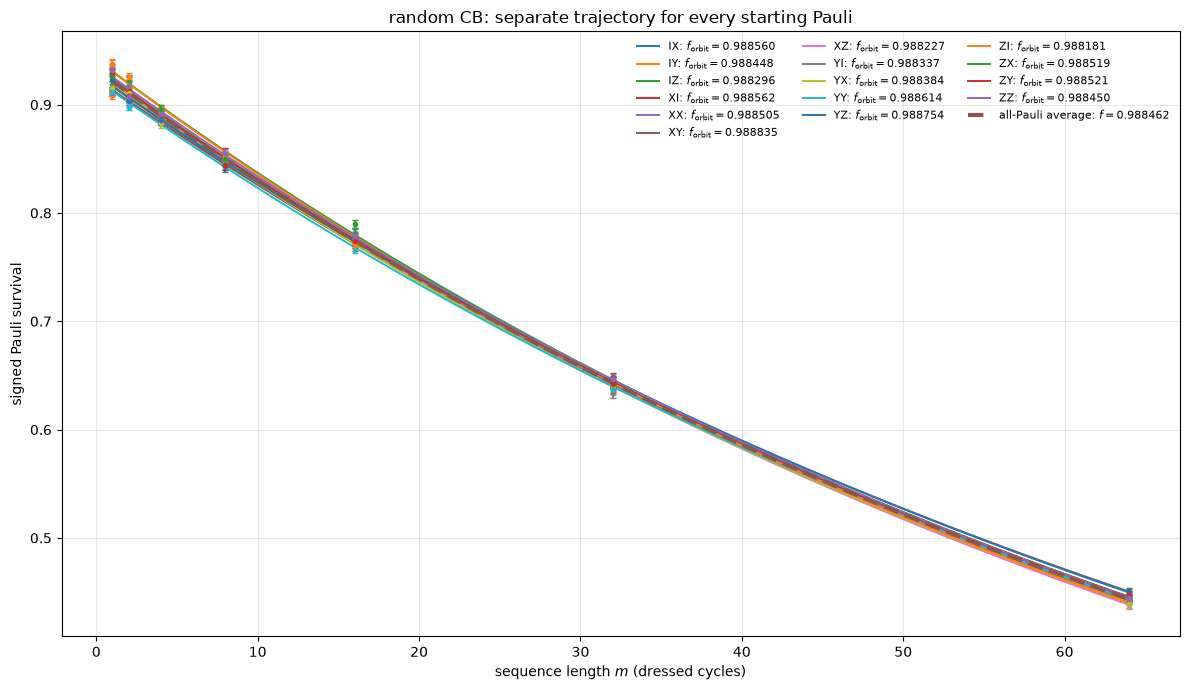

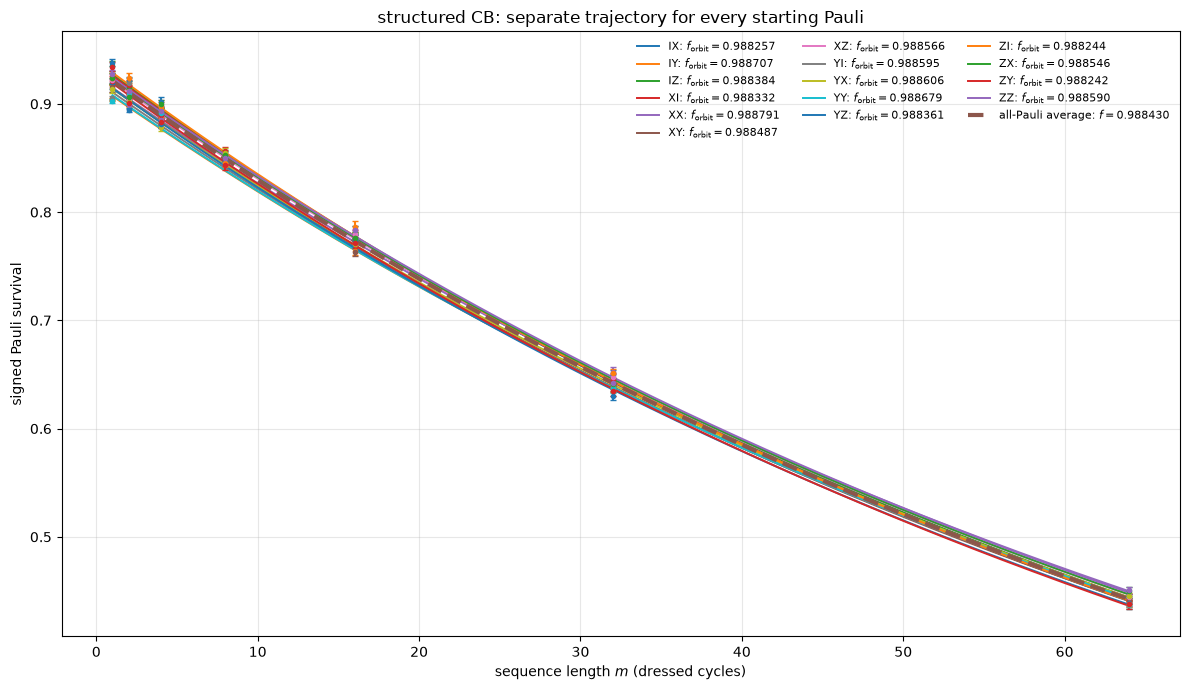

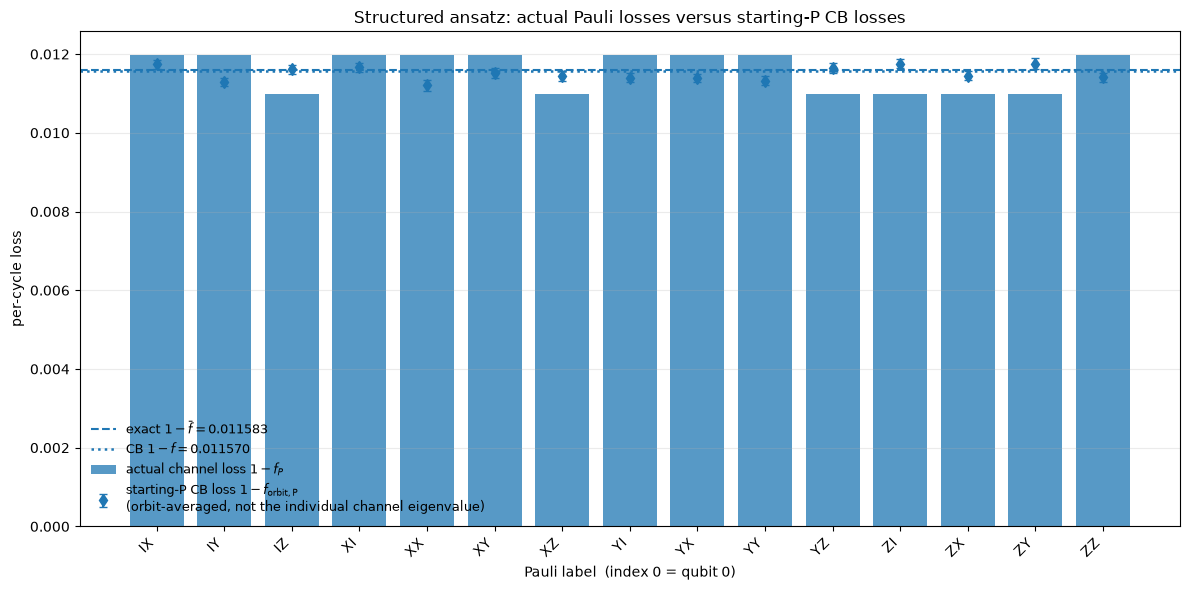

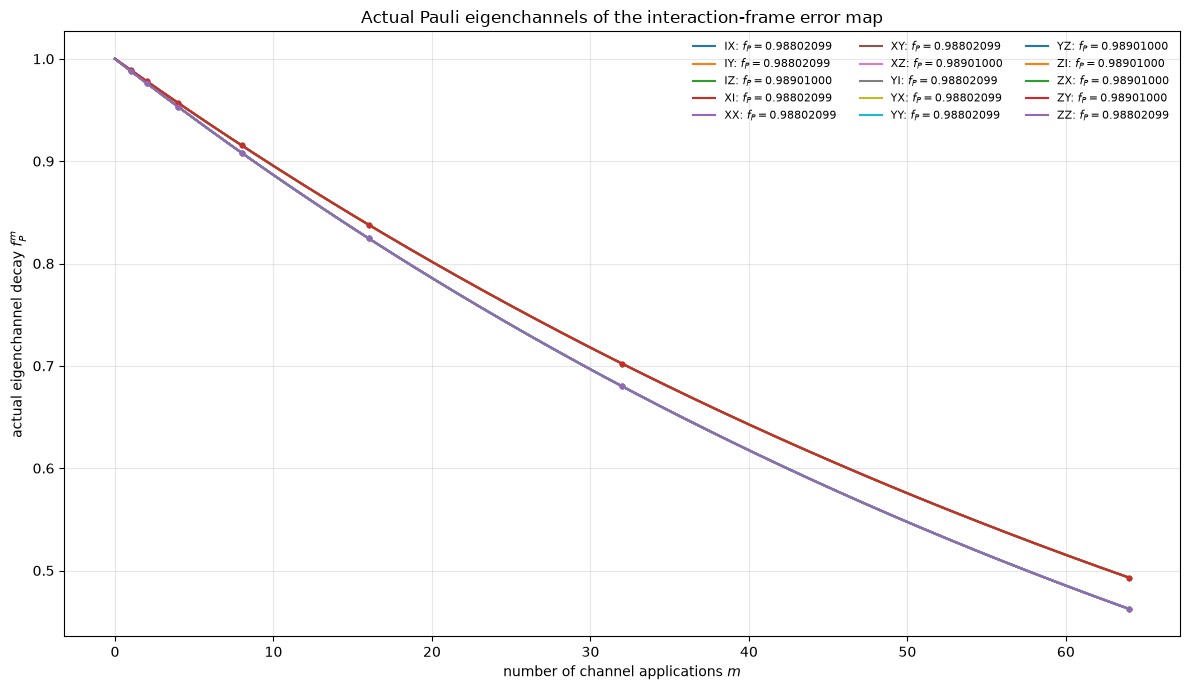

In [100]:
exact = exact_pauli_fidelities()

# All 15 starting-P CB trajectories, plus their average.
plot_cb_decay(cbs)

# Compare actual eigenvalues with structured orbit-averaged fits.
plot_cb_pauli_spectrum(
    cbs["structured"],
    exact,
    title=(
        "Structured ansatz: actual Pauli losses "
        "versus starting-P CB losses"
    ),
)

# Plot all 15 actual interaction-frame eigenchannel decays.
plot_exact_pauli_channel_decays(
    exact=exact,
    depths=CB_DEPTHS,
)

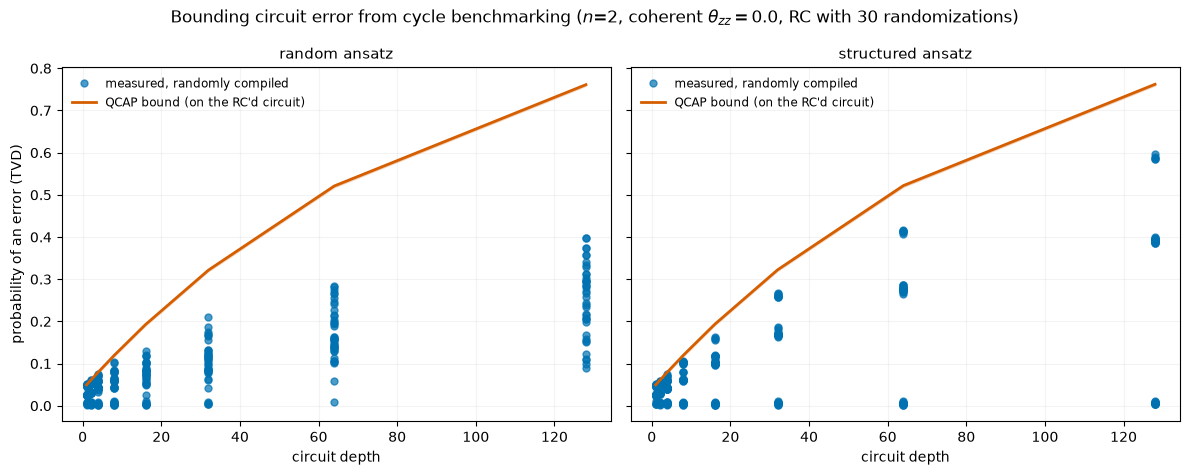

In [102]:
plot_bound_vs_depth(results, "probability of an error (TVD)", "tvd",
                    title="Bounding circuit error from cycle benchmarking "
                          f"($n$={N_QUBITS}, coherent "
                          rf"$\theta_{{zz}}={THETA_ZZ}$, RC with {N_RC} randomizations)")

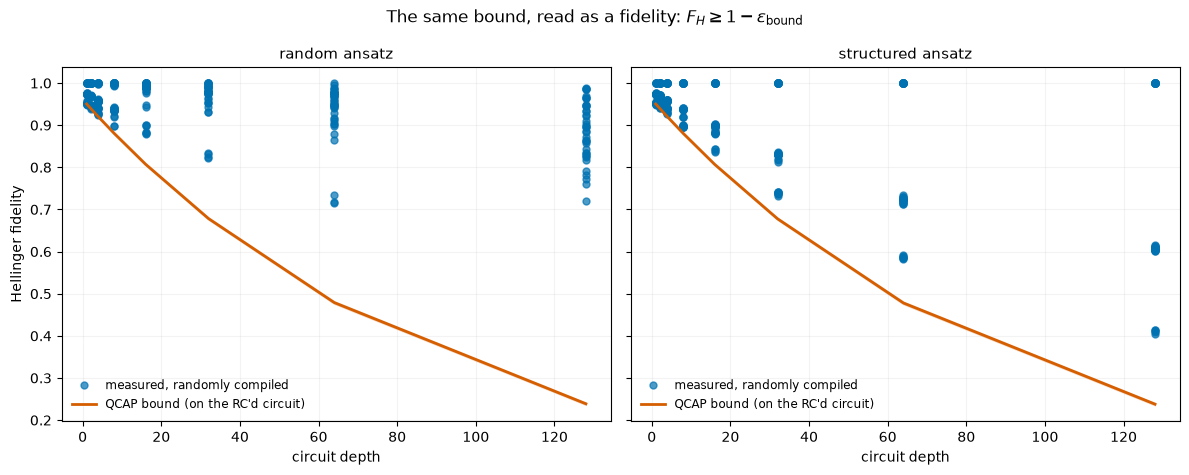

In [103]:
plot_bound_vs_depth(results, "Hellinger fidelity", "hellinger",
                    transform=lambda v: 1.0 - v,
                    title="The same bound, read as a fidelity: "
                          r"$F_H \geq 1 - \varepsilon_{\rm bound}$")